In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, matthews_corrcoef, recall_score
from sklearn.model_selection import LeaveOneOut
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Hazır ✓")

Hazır ✓


In [ ]:
from google.colab import files

print("train_data.txt dosyasını yükle:")
uploaded = files.upload()

train_data.txt dosyasını yükle:


Saving train_data.txt to train_data.txt


In [ ]:
train = np.loadtxt("train_data.txt", delimiter=",")

train_subjects = train[:, 0]       # column 1: subject id
train_X        = train[:, 1:27]    # columns 2-27: 26 features
train_updrs    = train[:, 27]      # column 28: UPDRS
train_y        = train[:, 28]      # column 29: class (0=Healthy, 1=PD)

feature_names = [
    'Jitter_local', 'Jitter_local_abs', 'Jitter_rap', 'Jitter_ppq5', 'Jitter_ddp',
    'Shimmer_local', 'Shimmer_local_dB', 'Shimmer_apq3', 'Shimmer_apq5', 'Shimmer_apq11', 'Shimmer_dda',
    'AC', 'NTH', 'HTN',
    'Median_pitch', 'Mean_pitch', 'Std_pitch', 'Min_pitch', 'Max_pitch',
    'Num_pulses', 'Num_periods', 'Mean_period', 'Std_period',
    'Fraction_unvoiced', 'Num_voice_breaks', 'Degree_voice_breaks'
]

n_subjects = len(np.unique(train_subjects))
n_pd = len(np.unique(train_subjects[train_y == 1]))
n_hc = len(np.unique(train_subjects[train_y == 0]))

print(f"Toplam kayıt      : {train.shape[0]}")
print(f"Toplam denek      : {n_subjects}")
print(f"Özellik sayısı    : {train_X.shape[1]}")
print(f"PD denek sayısı   : {n_pd}")
print(f"Sağlıklı denek    : {n_hc}")

Toplam kayıt      : 1040
Toplam denek      : 40
Özellik sayısı    : 26
PD denek sayısı   : 20
Sağlıklı denek    : 20


In [ ]:
def vif_hesapla(X):
    """
    X: ölçeklenmiş numpy array
    """
    vif_list = []
    for i in range(X.shape[1]):
        vif_list.append(variance_inflation_factor(X, i))
    return vif_list


def iteratif_vif_azalt_train_fold(X_train_scaled, feature_names, esik=10.0, verbose=False):
    """
    Sadece TRAIN fold üzerinde VIF azaltma yapar.

    Döndürür:
        secilen_idx   : orijinal feature indexleri
        secilen_names : kalan feature isimleri
        cikarilanlar  : çıkarılan feature isimleri
    """
    secilen_idx = list(range(X_train_scaled.shape[1]))
    secilen_names = feature_names.copy()
    cikarilanlar = []

    adim = 1
    while True:
        X_current = X_train_scaled[:, secilen_idx]
        vif_degerleri = vif_hesapla(X_current)
        max_vif = max(vif_degerleri)

        if max_vif <= esik:
            break

        en_kotu_local_idx = int(np.argmax(vif_degerleri))
        en_kotu_name = secilen_names[en_kotu_local_idx]

        if verbose:
            print(f"  Adım {adim}: Çıkarıldı -> {en_kotu_name:30s} VIF = {max_vif:.2f}")

        cikarilanlar.append(en_kotu_name)
        secilen_names.pop(en_kotu_local_idx)
        secilen_idx.pop(en_kotu_local_idx)
        adim += 1

    return secilen_idx, secilen_names, cikarilanlar

In [ ]:
def ozetle(X_scaled, mask, kombinasyon):
    """
    Bir deneğin kayıtlarını verilen kombinasyona göre özetler.
    """
    parcalar = []

    for metrik in kombinasyon:
        X_subj = X_scaled[mask]

        if metrik == 'mean':
            parcalar.append(X_subj.mean(axis=0))

        elif metrik == 'std':
            parcalar.append(X_subj.std(axis=0))

        elif metrik == 'median':
            parcalar.append(np.median(X_subj, axis=0))

        elif metrik == 'mad':   # Mean Absolute Deviation
            parcalar.append(np.mean(np.abs(X_subj - X_subj.mean(axis=0)), axis=0))

        elif metrik == 'medad': # Median Absolute Deviation
            med = np.median(X_subj, axis=0)
            parcalar.append(np.median(np.abs(X_subj - med), axis=0))

        elif metrik == 'iqr':
            q75 = np.percentile(X_subj, 75, axis=0)
            q25 = np.percentile(X_subj, 25, axis=0)
            parcalar.append(q75 - q25)

        elif metrik == 'p90_p10':
            q90 = np.percentile(X_subj, 90, axis=0)
            q10 = np.percentile(X_subj, 10, axis=0)
            parcalar.append(q90 - q10)

        elif metrik == 'trimmed_mean_10':
            from scipy.stats import trim_mean
            parcalar.append(trim_mean(X_subj, 0.10, axis=0))

        elif metrik == 'trimmed_mean_25':
            from scipy.stats import trim_mean
            parcalar.append(trim_mean(X_subj, 0.25, axis=0))

        else:
            raise ValueError(f"Bilinmeyen metrik: {metrik}")

    return np.hstack(parcalar)

In [ ]:
def sloo_vif_icte(X, subjects, y, feature_names, clf, kombinasyon=('mean', 'std'), vif_esik=10.0, verbose=False):
    """
    Leakage olmayan s-LOO:
    Her fold'da:
      1) test subject ayrılır
      2) scaler sadece train'e fit edilir
      3) VIF sadece train üzerinde uygulanır
      4) test aynı scaler + aynı seçili featurelarla dönüştürülür
      5) subject-level özet çıkarılır
      6) train subjects ile model eğitilir, test subject tahmin edilir
    """
    unique_subjects = np.unique(subjects)

    preds = []
    truths = []

    fold_detaylari = []

    for test_subject in unique_subjects:
        train_mask_subject = subjects != test_subject
        test_mask_subject  = subjects == test_subject

        X_train_raw = X[train_mask_subject]
        X_test_raw  = X[test_mask_subject]

        y_train_raw = y[train_mask_subject]
        y_test_raw  = y[test_mask_subject]

        subj_train = subjects[train_mask_subject]
        subj_test  = subjects[test_mask_subject]

        # 1) scaler sadece train kayıtlarına fit edilir
        scaler = StandardScaler()
        X_train_scaled_full = scaler.fit_transform(X_train_raw)
        X_test_scaled_full  = scaler.transform(X_test_raw)

        # 2) VIF sadece train fold üzerinde yapılır
        secilen_idx, secilen_names, cikarilanlar = iteratif_vif_azalt_train_fold(
            X_train_scaled_full,
            feature_names=feature_names,
            esik=vif_esik,
            verbose=False
        )

        X_train_scaled = X_train_scaled_full[:, secilen_idx]
        X_test_scaled  = X_test_scaled_full[:, secilen_idx]

        # 3) TRAIN tarafında her subject için özet çıkar
        X_train_ozet = []
        y_train_ozet = []

        for s in np.unique(subj_train):
            mask = subj_train == s
            X_train_ozet.append(ozetle(X_train_scaled, mask, kombinasyon))
            y_train_ozet.append(y_train_raw[mask][0])

        X_train_ozet = np.array(X_train_ozet)
        y_train_ozet = np.array(y_train_ozet)

        # 4) TEST tarafında tek subject için özet çıkar
        X_test_ozet = ozetle(X_test_scaled, np.ones(len(subj_test), dtype=bool), kombinasyon).reshape(1, -1)
        y_test_ozet = y_test_raw[0]

        # 5) Model eğit / tahmin et
        clf.fit(X_train_ozet, y_train_ozet)
        y_pred = clf.predict(X_test_ozet)[0]

        preds.append(y_pred)
        truths.append(y_test_ozet)

        fold_detaylari.append({
            "test_subject": test_subject,
            "n_features_after_vif": len(secilen_idx),
            "removed_features": cikarilanlar
        })

        if verbose:
            print(f"Test subject: {int(test_subject)} | Kalan feature: {len(secilen_idx)} | Tahmin: {int(y_pred)} | Gerçek: {int(y_test_ozet)}")

    results = {
        "Accuracy": round(accuracy_score(truths, preds) * 100, 2),
        "MCC": round(matthews_corrcoef(truths, preds), 4),
        "Sensitivity": round(recall_score(truths, preds, pos_label=1, zero_division=0) * 100, 2),
        "Specificity": round(recall_score(truths, preds, pos_label=0, zero_division=0) * 100, 2),
        "Predictions": preds,
        "Truths": truths,
        "FoldDetails": fold_detaylari
    }

    return results

In [ ]:
clf = SVC(kernel='linear', C=1)

res = sloo_vif_icte(
    X=train_X,
    subjects=train_subjects,
    y=train_y,
    feature_names=feature_names,
    clf=clf,
    kombinasyon=('mean', 'std'),
    vif_esik=10.0,
    verbose=False
)

print("Sonuçlar:")
print(res["Accuracy"], res["MCC"], res["Sensitivity"], res["Specificity"])

Sonuçlar:
57.5 0.1502 60.0 55.0


In [ ]:
denemeler = [
    ('Linear C=0.1',       'linear',   0.1,   'scale'),
    ('Linear C=1',         'linear',   1,     'scale'),
    ('Linear C=10',        'linear',   10,    'scale'),
    ('Linear C=100',       'linear',   100,   'scale'),

    ('RBF C=1 g=auto',     'rbf',      1,     'auto'),
    ('RBF C=10 g=0.005',   'rbf',      10,    0.005),
    ('RBF C=10 g=0.01',    'rbf',      10,    0.01),
    ('RBF C=10 g=0.1',     'rbf',      10,    0.1),
    ('RBF C=100 g=0.005',  'rbf',      100,   0.005),
    ('RBF C=100 g=0.01',   'rbf',      100,   0.01),

    ('Poly d=2 C=10',      'poly',     10,    'scale'),
    ('Poly d=3 C=10',      'poly',     10,    'scale'),
    ('Sigmoid C=10',       'sigmoid',  10,    'scale'),
]

kombinasyonlar = [
    ('mean', 'std'),
    ('median', 'iqr'),
    ('mean', 'mad'),
    ('trimmed_mean_10', 'iqr'),
    ('trimmed_mean_25', 'iqr'),
    ('median', 'medad'),
    ('median', 'p90_p10'),
]

In [ ]:
# VIF'in her fold'da aynı sonucu verip vermediğini kontrol et
from sklearn.svm import SVC

res_test = sloo_vif_icte(
    X=train_X,
    subjects=train_subjects,
    y=train_y,
    feature_names=feature_names,
    clf=SVC(kernel='linear', C=10),
    kombinasyon=('mean', 'std'),
    vif_esik=10.0,
    verbose=False
)

print("İlk 5 fold VIF sonuçları:")
for fold in res_test['FoldDetails'][:5]:
    print(f"  Fold {int(fold['test_subject'])}: kalan={fold['n_features_after_vif']} | çıkarılan={fold['removed_features']}")

İlk 5 fold VIF sonuçları:
  Fold 1: kalan=18 | çıkarılan=['Shimmer_dda', 'Jitter_rap', 'Num_pulses', 'AC', 'Mean_pitch', 'Jitter_local', 'Shimmer_local', 'Std_pitch']
  Fold 2: kalan=18 | çıkarılan=['Shimmer_dda', 'Jitter_rap', 'Num_pulses', 'AC', 'Mean_pitch', 'Jitter_local', 'Shimmer_local', 'Std_pitch']
  Fold 3: kalan=19 | çıkarılan=['Shimmer_dda', 'Jitter_rap', 'Num_pulses', 'AC', 'Mean_pitch', 'Jitter_local', 'Shimmer_local']
  Fold 4: kalan=19 | çıkarılan=['Shimmer_dda', 'Jitter_rap', 'Num_pulses', 'AC', 'Mean_pitch', 'Jitter_local', 'Shimmer_local']
  Fold 5: kalan=18 | çıkarılan=['Shimmer_dda', 'Jitter_rap', 'Num_pulses', 'AC', 'Mean_pitch', 'Jitter_local', 'Shimmer_local', 'Std_pitch']


In [ ]:
sonuclar = []

print(f"{'Model':<22} {'Kombinasyon':<28} {'Acc':>6} {'MCC':>8} {'Sens':>7} {'Spec':>7}")
print("-" * 82)

for isim, kernel, C, gamma in denemeler:
    for kombin in kombinasyonlar:
        if kernel == 'poly':
            degree = 3 if 'd=3' in isim else 2
            clf = SVC(kernel=kernel, C=C, gamma=gamma, degree=degree)
        else:
            clf = SVC(kernel=kernel, C=C, gamma=gamma)

        res = sloo_vif_icte(
            X=train_X,
            subjects=train_subjects,
            y=train_y,
            feature_names=feature_names,
            clf=clf,
            kombinasyon=kombin,
            vif_esik=10.0,
            verbose=False
        )

        row = {
            "Model": isim,
            "Kombinasyon": "+".join(kombin),
            "Kernel": kernel,
            "C": C,
            "Gamma": str(gamma),
            "Accuracy": res["Accuracy"],
            "MCC": res["MCC"],
            "Sensitivity": res["Sensitivity"],
            "Specificity": res["Specificity"]
        }
        sonuclar.append(row)

        print(f"{isim:<22} {('+'.join(kombin)):<28} {res['Accuracy']:>6} {res['MCC']:>8} {res['Sensitivity']:>7} {res['Specificity']:>7}")

Model                  Kombinasyon                     Acc      MCC    Sens    Spec
----------------------------------------------------------------------------------
Linear C=0.1           mean+std                       50.0      0.0    50.0    50.0
Linear C=0.1           median+iqr                     67.5   0.3504    70.0    65.0
Linear C=0.1           mean+mad                       45.0  -0.1005    50.0    40.0
Linear C=0.1           trimmed_mean_10+iqr            60.0    0.201    65.0    55.0
Linear C=0.1           trimmed_mean_25+iqr            62.5   0.2503    60.0    65.0
Linear C=0.1           median+medad                   72.5   0.4648    85.0    60.0
Linear C=0.1           median+p90_p10                 55.0   0.1021    65.0    45.0
Linear C=1             mean+std                       57.5   0.1502    60.0    55.0
Linear C=1             median+iqr                     75.0   0.5025    70.0    80.0
Linear C=1             mean+mad                       65.0   0.3015    70.0  

In [ ]:
df = pd.DataFrame(sonuclar)
df = df.sort_values(["Accuracy", "MCC"], ascending=False).reset_index(drop=True)

display(df.style
        .background_gradient(subset=["Accuracy", "MCC"], cmap="RdYlGn")
        .format({
            "Accuracy": "{:.2f}",
            "MCC": "{:.4f}",
            "Sensitivity": "{:.2f}",
            "Specificity": "{:.2f}"
        }))

,Model,Kombinasyon,Kernel,C,Gamma,Accuracy,MCC,Sensitivity,Specificity
0,Linear C=10,mean+std,linear,10.000000,scale,82.50,0.6574,90.00,75.00
1,Linear C=100,mean+std,linear,100.000000,scale,77.50,0.5563,85.00,70.00
2,RBF C=10 g=0.01,median+medad,rbf,10.000000,0.01,75.00,0.5103,85.00,65.00
3,Linear C=1,median+iqr,linear,1.000000,scale,75.00,0.5025,70.00,80.00
4,Linear C=10,median+medad,linear,10.000000,scale,75.00,0.5000,75.00,75.00
5,Linear C=0.1,median+medad,linear,0.100000,scale,72.50,0.4648,85.00,60.00
6,RBF C=10 g=0.1,median+medad,rbf,10.000000,0.1,72.50,0.4551,65.00,80.00
7,Linear C=1,median+medad,linear,1.000000,scale,72.50,0.4506,70.00,75.00
8,RBF C=100 g=0.005,trimmed_mean_25+iqr,rbf,100.000000,0.005,72.50,0.4506,75.00,70.00
9,RBF C=100 g=0.01,trimmed_mean_25+iqr,rbf,100.000000,0.01,72.50,0.4506,70.00,75.00


In [ ]:
en_iyi = df.iloc[0]

print("En iyi sonuç")
print(f"Model       : {en_iyi['Model']}")
print(f"Kombinasyon : {en_iyi['Kombinasyon']}")
print(f"Accuracy    : {en_iyi['Accuracy']}%")
print(f"MCC         : {en_iyi['MCC']}")
print(f"Sensitivity : {en_iyi['Sensitivity']}%")
print(f"Specificity : {en_iyi['Specificity']}%")

En iyi sonuç
Model       : Linear C=10
Kombinasyon : mean+std
Accuracy    : 82.5%
MCC         : 0.6574
Sensitivity : 90.0%
Specificity : 75.0%


In [ ]:
df_best = df.groupby("Kombinasyon", sort=False).first().reset_index()
df_best = df_best.sort_values("Accuracy", ascending=True)

renkler_kombin = {
    'mean+std': '#4C9BE8',
    'median+iqr': '#E8914C',
    'mean+mad': '#3fb950',
    'trimmed_mean_10+iqr': '#9b59b6',
    'trimmed_mean_25+iqr': '#e74c3c',
    'median+medad': '#f39c12',
    'median+p90_p10': '#1abc9c',
}
bar_renkleri = [renkler_kombin.get(k, '#999999') for k in df_best['Kombinasyon']]

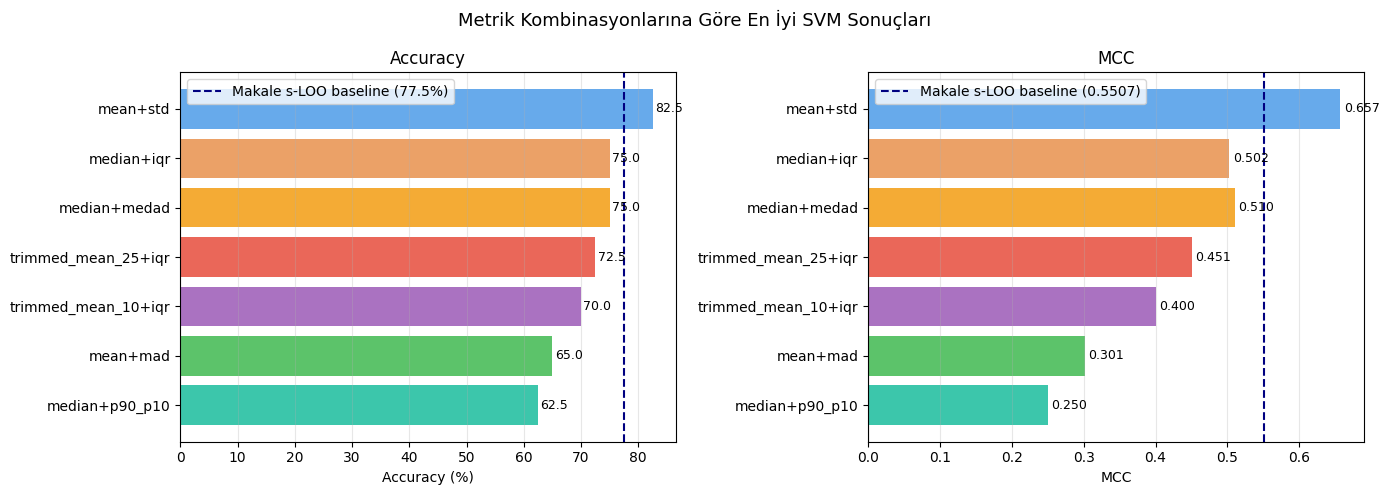

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Metrik Kombinasyonlarına Göre En İyi SVM Sonuçları", fontsize=13)

# Accuracy
axes[0].barh(df_best["Kombinasyon"], df_best["Accuracy"], color=bar_renkleri, alpha=0.85)
axes[0].axvline(x=77.5, color='navy', linestyle='--', linewidth=1.5, label='Makale s-LOO baseline (77.5%)')
axes[0].set_xlabel("Accuracy (%)")
axes[0].set_title("Accuracy")
axes[0].grid(axis='x', alpha=0.3)
axes[0].legend()

for i, v in enumerate(df_best["Accuracy"]):
    axes[0].text(v + 0.4, i, f"{v:.1f}", va='center', fontsize=9)

# MCC
axes[1].barh(df_best["Kombinasyon"], df_best["MCC"], color=bar_renkleri, alpha=0.85)
axes[1].axvline(x=0.5507, color='navy', linestyle='--', linewidth=1.5, label='Makale s-LOO baseline (0.5507)')
axes[1].axvline(x=0, color='gray', linewidth=0.8)
axes[1].set_xlabel("MCC")
axes[1].set_title("MCC")
axes[1].grid(axis='x', alpha=0.3)
axes[1].legend()

for i, v in enumerate(df_best["MCC"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig("svm_kombinasyon_karsilastirma_leakage_yok.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ==============================================
# ARAYÜZ İÇİN: Eğitim verisi ve config kaydet
# ==============================================

import joblib

# 1. EĞİTİM VERİSİNİ KAYDET (honest mod için lazım)
# Her tahminde 39 özne ile VIF + özetleme + SVM yeniden çalışacak
train_data_vif = {
    "X": train_X,
    "subjects": train_subjects,
    "y": train_y,
    "updrs": train_updrs,
    "feature_names": feature_names
}
joblib.dump(train_data_vif, "train_df_vif.pkl")
print("✓ train_df_vif.pkl kaydedildi")

# 2. HİPERPARAMETRELERİ KAYDET
config_vif = {
    "model_name": "VIF Sonrası Baseline (Linear SVM)",
    "thesis_section": "3.3",
    "kernel": "linear",
    "C": 10,
    "kombinasyon": ("mean", "std"),
    "vif_esik": 10.0,
    "thesis_accuracy": 0.825,
    "thesis_mcc": 0.6574,
    "thesis_sensitivity": 0.90,
    "thesis_specificity": 0.75
}
joblib.dump(config_vif, "config_vif.pkl")
print("✓ config_vif.pkl kaydedildi")

# 3. VIF SONRASI ORTALAMA KALAN ÖZELLİKLER (bilgi amaçlı)
# Tüm verisetinde VIF çalıştır (fold yok)
from sklearn.preprocessing import StandardScaler

scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(train_X)
secilen_idx_full, secilen_names_full, cikarilanlar_full = iteratif_vif_azalt_train_fold(
    X_full_scaled,
    feature_names=feature_names,
    esik=10.0,
    verbose=False
)

vif_info = {
    "kalan_ozellikler": secilen_names_full,
    "cikarilan_ozellikler": cikarilanlar_full,
    "kalan_sayisi": len(secilen_names_full),
    "cikarilan_sayisi": len(cikarilanlar_full)
}
joblib.dump(vif_info, "vif_features.pkl")
print(f"✓ vif_features.pkl kaydedildi")
print(f"  Tam veriseti VIF: {len(secilen_names_full)} özellik kaldı, {len(cikarilanlar_full)} çıkarıldı")
print(f"  Çıkarılan: {cikarilanlar_full}")

✓ train_df_vif.pkl kaydedildi
✓ config_vif.pkl kaydedildi
✓ vif_features.pkl kaydedildi
  Tam veriseti VIF: 18 özellik kaldı, 8 çıkarıldı
  Çıkarılan: ['Shimmer_dda', 'Jitter_rap', 'Num_pulses', 'AC', 'Mean_pitch', 'Jitter_local', 'Shimmer_local', 'Std_pitch']


In [ ]:
# ==============================================
# ARAYÜZÜN KULLANACAĞI HONEST TAHMİN FONKSİYONU
# Bir özneyi dışarıda tutar, kalan 39 ile yeniden:
# scaler + VIF + özetleme + Linear SVM yapar
# ==============================================

def predict_honest_vif(test_subject_id, train_data, config):
    """
    Honest s-LOO tahmin: Test öznesini dışarıda tutar.
    Senin sloo_vif_icte fonksiyonunun TEK ÖZNE versiyonudur.

    Parametreler:
    -----------
    test_subject_id : int (1-40)
    train_data : dict (X, subjects, y, feature_names)
    config : dict (kernel, C, kombinasyon, vif_esik)

    Döner:
    ------
    dict : Tahmin sonuçları
    """

    X = train_data["X"]
    subjects = train_data["subjects"]
    y = train_data["y"]
    feature_names_local = train_data["feature_names"]

    # Test öznesi var mı?
    if test_subject_id not in np.unique(subjects):
        return {"error": f"Özne {test_subject_id} bulunamadı"}

    # 1. Test öznesini ayır
    train_mask = subjects != test_subject_id
    test_mask = subjects == test_subject_id

    X_train_raw = X[train_mask]
    X_test_raw = X[test_mask]
    y_train_raw = y[train_mask]
    y_test_raw = y[test_mask]
    subj_train = subjects[train_mask]

    actual_class = int(y_test_raw[0])

    # 2. Scaler sadece train'e fit
    scaler = StandardScaler()
    X_train_scaled_full = scaler.fit_transform(X_train_raw)
    X_test_scaled_full = scaler.transform(X_test_raw)

    # 3. VIF sadece train üzerinde
    secilen_idx, secilen_names, cikarilanlar = iteratif_vif_azalt_train_fold(
        X_train_scaled_full,
        feature_names=feature_names_local,
        esik=config["vif_esik"],
        verbose=False
    )

    X_train_scaled = X_train_scaled_full[:, secilen_idx]
    X_test_scaled = X_test_scaled_full[:, secilen_idx]

    # 4. TRAIN özetleme (subject-bazlı)
    X_train_ozet = []
    y_train_ozet = []
    for s in np.unique(subj_train):
        mask = subj_train == s
        X_train_ozet.append(ozetle(X_train_scaled, mask, config["kombinasyon"]))
        y_train_ozet.append(y_train_raw[mask][0])
    X_train_ozet = np.array(X_train_ozet)
    y_train_ozet = np.array(y_train_ozet)

    # 5. TEST özetleme
    X_test_ozet = ozetle(X_test_scaled, np.ones(len(X_test_raw), dtype=bool), config["kombinasyon"]).reshape(1, -1)

    # 6. SVM eğit (probability=True - güven yüzdesi için)
    clf = SVC(kernel=config["kernel"], C=config["C"], probability=True)
    clf.fit(X_train_ozet, y_train_ozet)

    # 7. Tahmin
    prediction = int(clf.predict(X_test_ozet)[0])
    probabilities = clf.predict_proba(X_test_ozet)[0]

    predicted_label = "Parkinson Hastası (PD)" if prediction == 1 else "Sağlıklı Kontrol (HC)"
    actual_label = "Parkinson Hastası (PD)" if actual_class == 1 else "Sağlıklı Kontrol (HC)"
    is_correct = (prediction == actual_class)

    return {
        "subject_id": int(test_subject_id),
        "prediction": prediction,
        "predicted_label": predicted_label,
        "actual_class": actual_class,
        "actual_label": actual_label,
        "is_correct": is_correct,
        "confidence": float(probabilities[prediction]),
        "probabilities": {
            "HC": float(probabilities[0]),
            "PD": float(probabilities[1])
        },
        "vif_kept_features": secilen_names,
        "vif_removed_features": cikarilanlar,
        "n_features_after_vif": len(secilen_idx)
    }


# ==============================================
# TEST: 2 örnek ile fonksiyonu doğrula
# ==============================================
print("=" * 60)
print("HONEST TAHMİN TESTİ - Özne 1 (PD)")
print("=" * 60)

result_1 = predict_honest_vif(
    test_subject_id=1,
    train_data=train_data_vif,
    config=config_vif
)

print(f"Tahmin: {result_1['predicted_label']}")
print(f"Gerçek: {result_1['actual_label']}")
print(f"Doğru mu: {'✓ EVET' if result_1['is_correct'] else '✗ HAYIR'}")
print(f"Güven: %{result_1['confidence']*100:.2f}")
print(f"VIF sonrası özellik sayısı: {result_1['n_features_after_vif']}")

print("\n" + "=" * 60)
print("HONEST TAHMİN TESTİ - Özne 25 (HC)")
print("=" * 60)

result_25 = predict_honest_vif(
    test_subject_id=25,
    train_data=train_data_vif,
    config=config_vif
)

print(f"Tahmin: {result_25['predicted_label']}")
print(f"Gerçek: {result_25['actual_label']}")
print(f"Doğru mu: {'✓ EVET' if result_25['is_correct'] else '✗ HAYIR'}")
print(f"Güven: %{result_25['confidence']*100:.2f}")
print(f"VIF sonrası özellik sayısı: {result_25['n_features_after_vif']}")

HONEST TAHMİN TESTİ - Özne 1 (PD)
Tahmin: Parkinson Hastası (PD)
Gerçek: Parkinson Hastası (PD)
Doğru mu: ✓ EVET
Güven: %85.99
VIF sonrası özellik sayısı: 18

HONEST TAHMİN TESTİ - Özne 25 (HC)
Tahmin: Sağlıklı Kontrol (HC)
Gerçek: Sağlıklı Kontrol (HC)
Doğru mu: ✓ EVET
Güven: %82.90
VIF sonrası özellik sayısı: 18


In [ ]:
# ==============================================
# DOSYALARI YEREL BİLGİSAYARA İNDİR
# ==============================================

from google.colab import files

print("Dosyalar indiriliyor...")
files.download("train_df_vif.pkl")
files.download("config_vif.pkl")
files.download("vif_features.pkl")

print("\n✓ TAMAMLANDI!")
print("İndirilen dosyalar:")
print("  1. train_df_vif.pkl       (Eğitim verisi)")
print("  2. config_vif.pkl         (Hiperparametreler)")
print("  3. vif_features.pkl       (VIF bilgileri)")
print("\nFlask arayüzünün 'model/' klasörüne koyacağız.")

Dosyalar indiriliyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ TAMAMLANDI!
İndirilen dosyalar:
  1. train_df_vif.pkl       (Eğitim verisi)
  2. config_vif.pkl         (Hiperparametreler)
  3. vif_features.pkl       (VIF bilgileri)

Flask arayüzünün 'model/' klasörüne koyacağız.
